<div style="display:flex; align-items:center"><img src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" width="300"><img src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" width="200"><span style="margin-left:auto; text-align:right"><b>CaixaBank · Advanced Analytics Program</b><br>Python profesional para analítica avanzada</span></div>

# Laboratorio: optimización de un pipeline de datos — soluciones

Duración: 1,5 horas · Caso: informe mensual de operaciones

## El incidente

El informe diario funciona. Al cerrar el mes, recibe muchos más registros: consume demasiada memoria y termina tarde. Investigamos una pregunta cada vez: qué ocupa memoria, qué datos retenemos sin necesitarlos y qué efecto tiene cada decisión sobre el tiempo.

Aplicamos: medir → localizar el coste → cambiar una causa → validar.

# Parte guiada — resolver el incidente paso a paso

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.testing import assert_frame_equal

sns.set_theme(style='whitegrid', context='notebook')

In [2]:
def generar_operaciones(n_filas=1_000_000, semilla=42):
    rng = np.random.default_rng(semilla)
    return pd.DataFrame({
        'operacion_id': np.arange(1, n_filas + 1),
        'region': rng.choice(['norte', 'sur', 'este', 'oeste'], n_filas),
        'canal': rng.choice(['digital', 'oficina', 'partner'], n_filas, p=[.58, .30, .12]),
        'producto': rng.choice(['cuenta', 'tarjeta', 'prestamo', 'inversion'], n_filas),
        'estado': rng.choice(['confirmada', 'pendiente', 'cancelada'], n_filas, p=[.78, .16, .06]),
        'segmento': rng.choice(['retail', 'premium', 'empresa'], n_filas),
        'unidades': rng.integers(1, 120, n_filas),
        'precio_unitario': rng.uniform(12, 2_000, n_filas).round(2),
        'descuento': rng.choice([0.0, .03, .05, .10], n_filas),
        'score_riesgo': rng.uniform(0, 1, n_filas),
        'referencia_externa': [f'EXT-{i:07d}' for i in range(n_filas)],
        'comentario_origen': rng.choice(['carga diaria', 'revision manual', 'origen externo'], n_filas),
    })

def memoria_mb(datos):
    return datos.memory_usage(deep=True).sum() / 1024**2

def auditar_memoria(datos):
    tabla = pd.DataFrame({'dtype': datos.dtypes.astype(str), 'valores_unicos': datos.nunique(dropna=False), 'memoria_mb': datos.memory_usage(deep=True) / 1024**2})
    tabla['ratio_unicos'] = tabla['valores_unicos'] / len(datos)
    return tabla.sort_values('memoria_mb', ascending=False)

def graficar_memoria(tabla, titulo):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=tabla.reset_index(), x='memoria_mb', y='index', color='#0066a6')
    plt.xlabel('Memoria (MB)'); plt.ylabel('Columna'); plt.title(titulo); sns.despine(); plt.show()

Memoria total: 148.6 MB


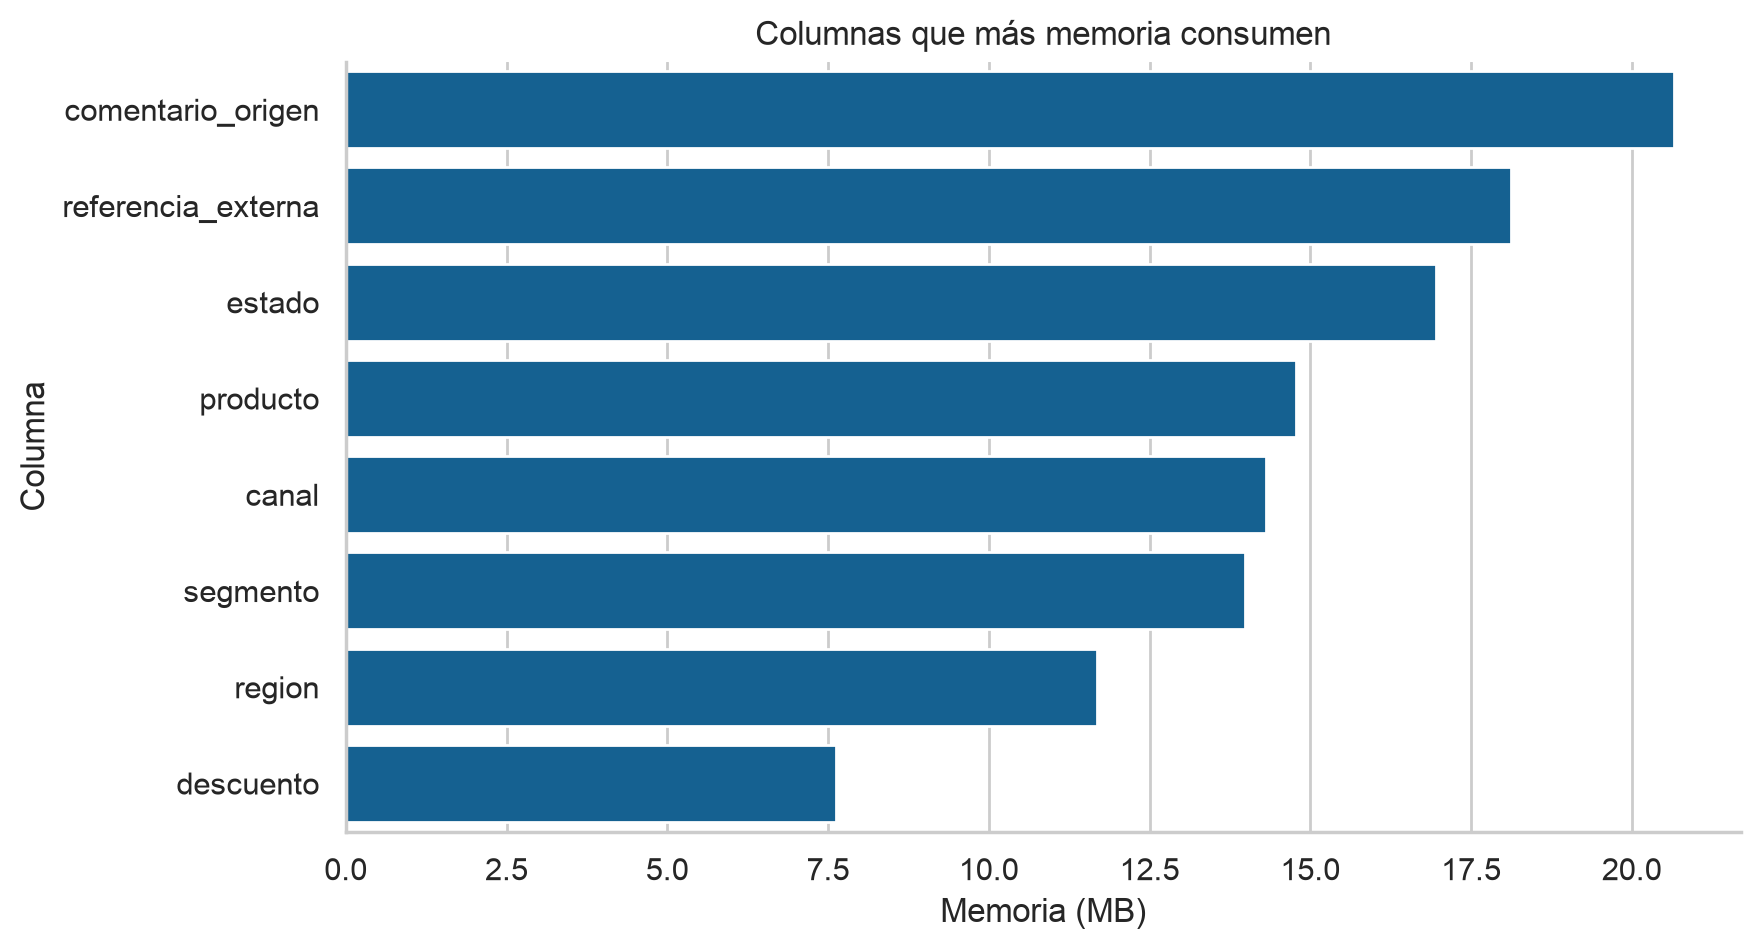

In [3]:
operaciones = generar_operaciones()
auditoria_inicial = auditar_memoria(operaciones)
print(f'Memoria total: {memoria_mb(operaciones):.1f} MB')
graficar_memoria(auditoria_inicial.head(8), 'Columnas que más memoria consumen')

Las categorías se reservan para texto repetido. No convertimos el identificador externo casi único ni reducimos el precio monetario.

In [4]:
def resumen_reduccion_memoria(antes, despues, etiqueta):
    antes_mb, despues_mb = memoria_mb(antes), memoria_mb(despues)
    return pd.DataFrame([{'caso': etiqueta, 'antes_mb': antes_mb, 'despues_mb': despues_mb, 'ahorro_mb': antes_mb - despues_mb, 'reduccion_pct': 100 * (antes_mb - despues_mb) / antes_mb}])

COLUMNAS_CATEGORIA = ['region', 'canal', 'producto', 'estado', 'segmento', 'comentario_origen']

def compactar_operaciones(datos):
    salida = datos.copy()
    for columna in COLUMNAS_CATEGORIA:
        salida[columna] = salida[columna].astype('category')
    salida['unidades'] = pd.to_numeric(salida['unidades'], downcast='unsigned')
    salida['score_riesgo'] = pd.to_numeric(salida['score_riesgo'], downcast='float')
    return salida

operaciones_compactas = compactar_operaciones(operaciones)
print(f'Memoria total: {memoria_mb(operaciones_compactas):.1f} MB')
print(f'Reducción de memoria de un {memoria_mb(operaciones)/memoria_mb(operaciones_compactas) * 100} %')
comparacion_tipos = pd.DataFrame({'antes_mb': auditar_memoria(operaciones)['memoria_mb'], 'despues_mb': auditar_memoria(operaciones_compactas)['memoria_mb']})
comparacion_tipos['ahorro_mb'] = comparacion_tipos['antes_mb'] - comparacion_tipos['despues_mb']
resumen_caso_1 = resumen_reduccion_memoria(operaciones, operaciones_compactas, 'tipos del origen')
resumen_caso_1

Memoria total: 51.5 MB
Reducción de memoria de un 288.62933284543624 %


,caso,antes_mb,despues_mb,ahorro_mb,reduccion_pct
0,tipos del origen,148.640779,51.498847,97.141932,65.353487


In [5]:
for columna in ['region', 'canal', 'producto', 'estado', 'segmento', 'comentario_origen', 'unidades']:
    assert operaciones[columna].astype(str).equals(operaciones_compactas[columna].astype(str))
np.testing.assert_allclose(operaciones['score_riesgo'], operaciones_compactas['score_riesgo'], rtol=1e-6)
print('Tipos compactados y valores validados.')

Tipos compactados y valores validados.


## Segunda evidencia: el pipeline conserva demasiado

Compactar reduce el origen, pero el informe todavía puede crear objetos intermedios grandes. Comparamos tres versiones: base, tipos compactos y tipos compactos con un pipeline ordenado.

In [6]:
COLUMNAS_INFORME = ['region', 'canal', 'estado', 'unidades', 'precio_unitario', 'descuento']

def registrar_etapa(registro, nombre, datos):
    registro.append({'etapa': nombre, 'filas': len(datos), 'columnas': datos.shape[1], 'memoria_mb': memoria_mb(datos)})

def informe_original(datos, devolver_traza=False):
    traza = []
    trabajo = datos.copy(); registrar_etapa(traza, 'copia completa', trabajo)
    trabajo['importe_neto'] = trabajo['unidades'] * trabajo['precio_unitario'] * (1 - trabajo['descuento'])
    registrar_etapa(traza, 'calcular antes de filtrar', trabajo)
    trabajo = trabajo.loc[trabajo['estado'].eq('confirmada')].copy(); registrar_etapa(traza, 'filtrar tarde', trabajo)
    informe = trabajo.groupby(['region', 'canal'], observed=True).agg(operaciones=('operacion_id', 'size'), importe_neto=('importe_neto', 'sum')).reset_index()
    return (informe, pd.DataFrame(traza)) if devolver_traza else informe

def informe_optimizado(datos, devolver_traza=False):
    traza = []
    trabajo = datos.loc[:, COLUMNAS_INFORME]; registrar_etapa(traza, 'seleccionar columnas', trabajo)
    trabajo = trabajo.loc[trabajo['estado'].eq('confirmada')]; registrar_etapa(traza, 'filtrar temprano', trabajo)
    trabajo = trabajo.assign(importe_neto=trabajo['unidades'] * trabajo['precio_unitario'] * (1 - trabajo['descuento']))
    registrar_etapa(traza, 'calcular sobre datos necesarios', trabajo)
    informe = trabajo.groupby(['region', 'canal'], observed=True).agg(operaciones=('estado', 'size'), importe_neto=('importe_neto', 'sum')).reset_index()
    return (informe, pd.DataFrame(traza)) if devolver_traza else informe

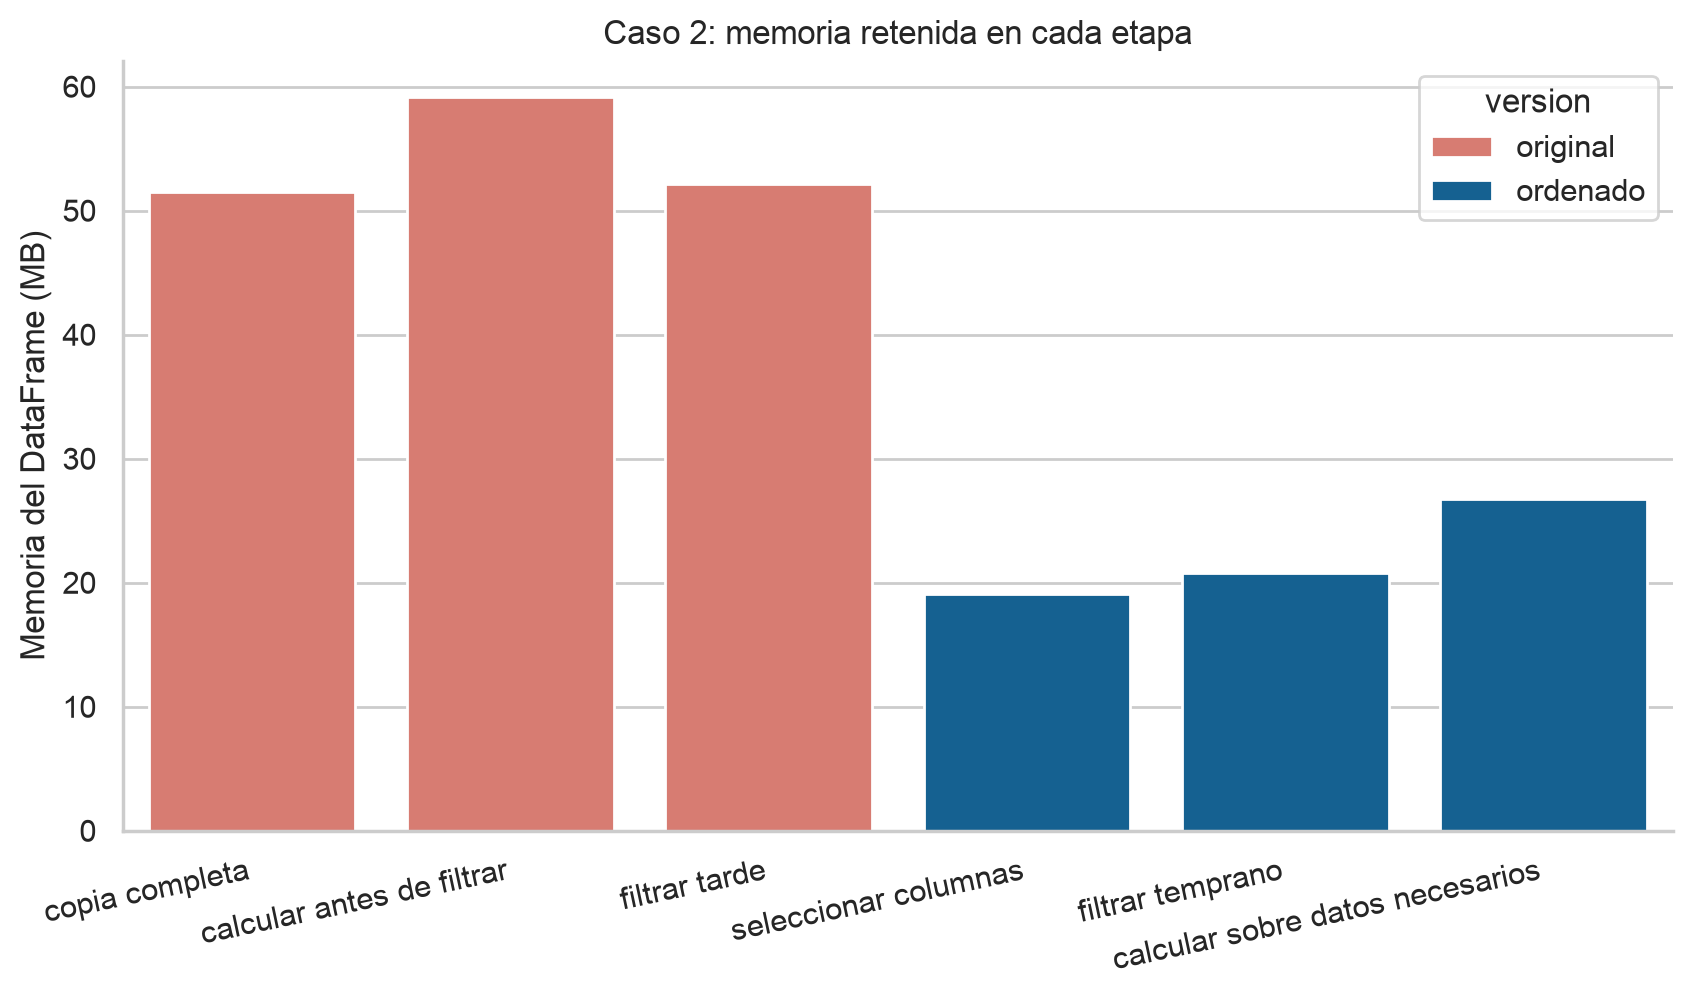

,etapa,filas,columnas,memoria_mb,version
0,copia completa,1000000,12,51.498847,original
1,calcular antes de filtrar,1000000,13,59.128242,original
2,filtrar tarde,779590,13,52.136593,original
3,seleccionar columnas,1000000,6,19.073857,ordenado
4,filtrar temprano,779590,6,20.817544,ordenado
5,calcular sobre datos necesarios,779590,7,26.765344,ordenado


In [7]:
resultado_original, traza_original = informe_original(operaciones_compactas, devolver_traza=True)
resultado_optimizado, traza_optimizada = informe_optimizado(operaciones_compactas, devolver_traza=True)
assert_frame_equal(resultado_original, resultado_optimizado)

pico_original, pico_optimizado = traza_original['memoria_mb'].max(), traza_optimizada['memoria_mb'].max()
resumen_caso_2 = pd.DataFrame([{'caso': 'orden del pipeline', 'antes_mb': pico_original, 'despues_mb': pico_optimizado, 'ahorro_mb': pico_original - pico_optimizado, 'reduccion_pct': 100 * (pico_original - pico_optimizado) / pico_original}])
traza = pd.concat([traza_original.assign(version='original'), traza_optimizada.assign(version='ordenado')], ignore_index=True)
plt.figure(figsize=(10, 5))
sns.barplot(data=traza, x='etapa', y='memoria_mb', hue='version', palette=['#e86e61', '#0066a6'])
plt.xticks(rotation=12, ha='right'); plt.ylabel('Memoria del DataFrame (MB)'); plt.xlabel(''); plt.title('Caso 2: memoria retenida en cada etapa'); sns.despine(); plt.show()
traza

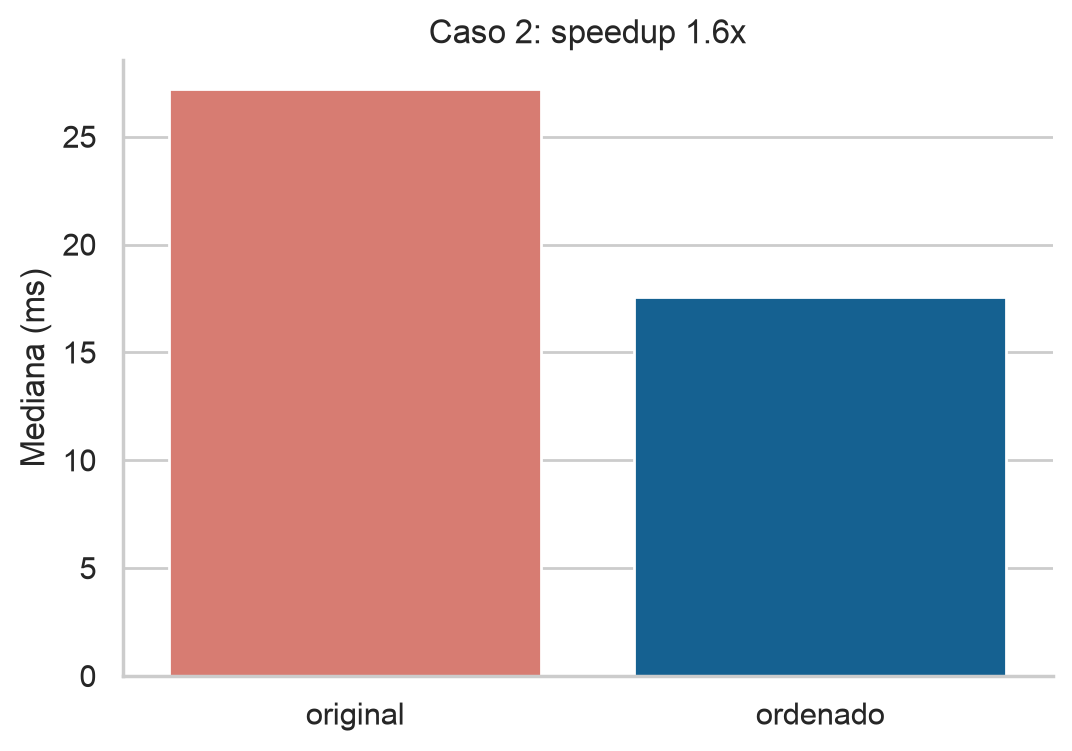

,version,mediana_ms,minimo_ms
0,original,27.196916,26.563084
1,ordenado,17.544500,17.307625


In [8]:
def medir(funcion, repeticiones=5):
    funcion(); tiempos = []
    for _ in range(repeticiones):
        inicio = perf_counter(); funcion(); tiempos.append((perf_counter() - inicio) * 1_000)
    return {'mediana_ms': float(np.median(tiempos)), 'minimo_ms': float(np.min(tiempos))}

medida_original = medir(lambda: informe_original(operaciones_compactas))
medida_optimizada = medir(lambda: informe_optimizado(operaciones_compactas))
comparacion_tiempo = pd.DataFrame([{'version': 'original', **medida_original}, {'version': 'ordenado', **medida_optimizada}])
speedup_caso_2 = medida_original['mediana_ms'] / medida_optimizada['mediana_ms']
plt.figure(figsize=(6, 4))
sns.barplot(data=comparacion_tiempo, x='version', y='mediana_ms', hue='version', palette=['#e86e61', '#0066a6'], legend=False)
plt.ylabel('Mediana (ms)'); plt.xlabel(''); plt.title(f'Caso 2: speedup {speedup_caso_2:.1f}x'); sns.despine(); plt.show()
comparacion_tiempo

# Práctica — soluciones

## Ejercicio 1 — Diagnóstico con evidencia

**Situación.** El nuevo origen tiene 120 000 operaciones y no podemos convertir texto a category de forma indiscriminada.

**Tarea.** Añade candidata_category: True cuando dtype es object y ratio_unicos es menor que 0.05. Muestra las candidatas ordenadas por memoria.

**Entrega.** Explica por qué referencia_externa queda fuera.

In [9]:
operaciones_practica = generar_operaciones(n_filas=120_000, semilla=7)
auditoria_practica = auditar_memoria(operaciones_practica)
auditoria_practica['candidata_category'] = (auditoria_practica['dtype'].eq('object') & auditoria_practica['ratio_unicos'].lt(0.05))
auditoria_practica.query('candidata_category').sort_values('memoria_mb', ascending=False)

,dtype,valores_unicos,memoria_mb,ratio_unicos,candidata_category


## Ejercicio 2 — Política de compactación

**Situación.** La política debe salir de la auditoría, no de una lista escrita a mano.

**Tarea.** Implementa compactar_practica: convierte candidatas, reduce unidades y score_riesgo, y conserva precio_unitario como float64.

**Entrega.** Devuelve un DataFrame nuevo sin modificar la entrada.

In [10]:
def compactar_practica(datos, auditoria):
    salida = datos.copy()
    candidatas = auditoria.index[auditoria['candidata_category']]
    for columna in candidatas:
        salida[columna] = salida[columna].astype('category')
    salida['unidades'] = pd.to_numeric(salida['unidades'], downcast='unsigned')
    salida['score_riesgo'] = pd.to_numeric(salida['score_riesgo'], downcast='float')
    return salida

## Ejercicio 3 — Cuantificar y validar el caso 1

**Situación.** El ahorro no es válido si cambia los datos que alimentan el informe.

**Tarea.** Informa ahorro absoluto y porcentual; valida texto, unidades, score_riesgo y que precio_unitario siga en float64.

**Entrega.** Tabla de reducción y validaciones sin error.

In [11]:
operaciones_practica_compactas = compactar_practica(operaciones_practica, auditoria_practica)
resumen_practica_1 = resumen_reduccion_memoria(operaciones_practica, operaciones_practica_compactas, 'caso 1 práctica')
for columna in auditoria_practica.query('candidata_category').index:
    assert operaciones_practica[columna].astype(str).equals(operaciones_practica_compactas[columna].astype(str))
assert str(operaciones_practica_compactas['precio_unitario'].dtype) == 'float64'
np.testing.assert_allclose(operaciones_practica['score_riesgo'], operaciones_practica_compactas['score_riesgo'], rtol=1e-6)
resumen_practica_1

,caso,antes_mb,despues_mb,ahorro_mb,reduccion_pct
0,caso 1 práctica,17.837454,16.578604,1.25885,7.057342


## Ejercicio 4 — Localizar el máximo del caso 2

**Situación.** El origen ya está compacto, pero el informe sigue generando intermedios grandes.

**Tarea.** Ejecuta informe_original con traza y devuelve cuello_memoria con la etapa de mayor memoria, sus filas, columnas y memoria_mb.

**Entrega.** Explica qué acción ocurre en esa etapa.

In [12]:
resultado_practica_original, traza_practica_original = informe_original(operaciones_practica_compactas, devolver_traza=True)
cuello_memoria = traza_practica_original.loc[[traza_practica_original['memoria_mb'].idxmax()]]
cuello_memoria

,etapa,filas,columnas,memoria_mb
1,calcular antes de filtrar,120000,13,17.494131


## Ejercicio 5 — Separar una mejora del pipeline

**Situación.** Antes de reescribir el informe aislamos una decisión: no arrastrar datos innecesarios.

**Tarea.** Crea preparar_temprano: seleccionar COLUMNAS_INFORME y filtrar confirmadas, en ese orden.

**Entrega.** Cuantifica el ahorro de esta única intervención.

In [13]:
def preparar_temprano(datos):
    trabajo = datos.loc[:, COLUMNAS_INFORME]
    return trabajo.loc[trabajo['estado'].eq('confirmada')]

preparadas = preparar_temprano(operaciones_practica_compactas)
resumen_preparacion = resumen_reduccion_memoria(operaciones_practica_compactas, preparadas, 'selección y filtro temprano')
resumen_preparacion

,caso,antes_mb,despues_mb,ahorro_mb,reduccion_pct
0,selección y filtro temprano,16.578604,6.300601,10.278003,61.995587


## Ejercicio 6 — Completar el caso 2

**Situación.** La preparación temprana funciona y debe integrarse sin perder reglas del informe.

**Tarea.** Implementa informe_practica, calcula importe_neto y agrega por region y canal.

**Entrega.** Función equivalente a informe_original y validación funcional.

In [14]:
def informe_practica(datos):
    trabajo = preparar_temprano(datos)
    trabajo = trabajo.assign(importe_neto=trabajo['unidades'] * trabajo['precio_unitario'] * (1 - trabajo['descuento']))
    return trabajo.groupby(['region', 'canal'], observed=True).agg(operaciones=('estado', 'size'), importe_neto=('importe_neto', 'sum')).reset_index()

assert_frame_equal(informe_original(operaciones_practica_compactas), informe_practica(operaciones_practica_compactas))
print('Caso 2 validado.')

Caso 2 validado.


## Ejercicio 7 — Defender la decisión

**Situación.** Debes decidir si el cambio entra en el pipeline mensual.

**Criterios de adopción.** Aplicamos la mejora únicamente si el resultado está validado, el máximo de memoria retenida baja al menos un 20 % y el speedup es como mínimo 1.10x.

**Tarea.** Calcula speedup y reducción de memoria; después usa los criterios para decidir aplicar, revisar o no aplicar la mejora.

**Entrega.** Diccionario con métricas, decisión y motivo que permita justificar la decisión sin releer el notebook.

In [15]:
resultado_practica_optimizado, traza_practica_optimizada = informe_optimizado(operaciones_practica_compactas, devolver_traza=True)
medida_practica_original = medir(lambda: informe_original(operaciones_practica_compactas))
medida_practica_optimizada = medir(lambda: informe_practica(operaciones_practica_compactas))
speedup_practica = medida_practica_original['mediana_ms'] / medida_practica_optimizada['mediana_ms']
pico_practica_original = traza_practica_original['memoria_mb'].max()
pico_practica_optimizada = traza_practica_optimizada['memoria_mb'].max()
resumen_practica_2 = pd.DataFrame([{'caso': 'caso 2 práctica', 'antes_mb': pico_practica_original, 'despues_mb': pico_practica_optimizada, 'ahorro_mb': pico_practica_original - pico_practica_optimizada, 'reduccion_pct': 100 * (pico_practica_original - pico_practica_optimizada) / pico_practica_original}])
CRITERIOS_ADOPCION = {'reduccion_memoria_min_pct': 20, 'speedup_min': 1.10}
resultado_validado = True
reduccion_memoria_practica = float(resumen_practica_2.loc[0, 'reduccion_pct'])
cumple_memoria = reduccion_memoria_practica >= CRITERIOS_ADOPCION['reduccion_memoria_min_pct']
cumple_tiempo = speedup_practica >= CRITERIOS_ADOPCION['speedup_min']

if not resultado_validado:
    decision, motivo = 'no aplicar', 'La salida no está validada frente al informe original.'
elif cumple_memoria and cumple_tiempo:
    decision, motivo = 'aplicar', 'Cumple validación, presupuesto de memoria y mejora mínima de tiempo.'
else:
    decision, motivo = 'revisar antes de aplicar', 'La salida es correcta, pero la evidencia de memoria o tiempo no alcanza el umbral.'

recomendacion = {'reduccion_memoria_pct': round(reduccion_memoria_practica, 2), 'speedup_pipeline': round(speedup_practica, 2), 'resultado_validado': resultado_validado, 'decision': decision, 'motivo': motivo}
recomendacion

{'reduccion_memoria_pct': 59.42,
 'speedup_pipeline': 1.73,
 'resultado_validado': True,
 'decision': 'aplicar',
 'motivo': 'Cumple validación, presupuesto de memoria y mejora mínima de tiempo.'}

## Extensión opcional — escalabilidad y presupuesto de memoria

Repite los casos 1 y 2 con 30 000, 120 000 y 480 000 filas. Construye una tabla con tamaño, memoria del origen, memoria compacta y máximo de memoria del pipeline ordenado. ¿Qué tamaño estimarías como límite prudente con un presupuesto de 512 MB? Justifica la estimación.

## Extensión experta — contrato de memoria

Diseña verificar_presupuesto(datos, limite_mb), que lance ValueError si el DataFrame supera el límite. Integra la comprobación antes del pipeline y decide qué columnas eliminarías o qué procesamiento por bloques investigarías si falla.

## Ayudas desplegables de los ejercicios

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 1</strong></summary>

~~~python
es_texto = auditoria_practica['dtype'].eq('object')
poca_cardinalidad = auditoria_practica['ratio_unicos'].lt(0.05)
auditoria_practica['candidata_category'] = ...  # TODO
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 2</strong></summary>

~~~python
salida = datos.copy()
candidatas = auditoria.index[auditoria['candidata_category']]
for columna in candidatas:
    salida[columna] = ...  # TODO: category
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 3</strong></summary>

~~~python
operaciones_practica_compactas = compactar_practica(operaciones_practica, auditoria_practica)
resumen_practica_1 = resumen_reduccion_memoria(operaciones_practica, operaciones_practica_compactas, 'caso 1 práctica')
assert ...  # TODO: validación
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 4</strong></summary>

~~~python
_, traza_practica_original = informe_original(operaciones_practica_compactas, devolver_traza=True)
indice_pico = traza_practica_original['memoria_mb'].idxmax()
cuello_memoria = ...  # TODO
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 5</strong></summary>

~~~python
trabajo = datos.loc[:, COLUMNAS_INFORME]
trabajo = ...  # TODO: filtra confirmadas
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 6</strong></summary>

~~~python
trabajo = preparar_temprano(datos)
trabajo = trabajo.assign(importe_neto=...)
informe = ...  # TODO: groupby y agregación
~~~
</details>

<details><summary><strong>Obtener esqueleto de ayuda para el ejercicio 7</strong></summary>

~~~python
CRITERIOS_ADOPCION = {'reduccion_memoria_min_pct': 20, 'speedup_min': 1.10}
# TODO: calcula reduccion_memoria_practica y resultado_validado.
cumple_memoria = ... >= CRITERIOS_ADOPCION['reduccion_memoria_min_pct']
cumple_tiempo = ... >= CRITERIOS_ADOPCION['speedup_min']

if resultado_validado and cumple_memoria and cumple_tiempo:
    decision = 'aplicar'
else:
    # TODO: usa revisar antes de aplicar o no aplicar y explica el motivo.
    decision = ...
~~~
</details>

## Preguntas para la discusión

1. ¿Por qué category puede ahorrar memoria en region pero no en una referencia casi única?
2. ¿Por qué mantener precio_unitario en float64 puede ser correcto?
3. ¿Qué diferencia hay entre la memoria de un DataFrame y el pico total de RAM?
4. ¿Por qué seleccionar columnas y filtrar filas temprano cambia el coste posterior?
5. ¿Qué validación exigirías antes de desplegar esta optimización en un informe regulado?